# Flow + membrane refinement — fine-tuning

Pick one FOV, define up to a few parameter settings, and look at them side by side.

Run order: **1 → 2 → 3 → 4**. Change the FOV in 2 or the settings in 3 and re-run
cell 4 as often as you like.

Use the `mohit` kernel.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.morphology import dilation, disk

import flow_membrane_seg as fm          # same folder as this notebook

# Folder of Cellpose *_seg.npy files
SEG_DIR = Path("/omics/odcf/analysis/OE0622_projects/mibi_shared/Amir/preprocessing"
               "/segmentation/positivity_map_v3/sorted_by_quality/High/whole_cell"
               "/TN2_hiRes_Amir_posMap2")

ALL_FOVS = sorted(SEG_DIR.glob("*_seg.npy"))
print(f"{len(ALL_FOVS)} FOVs in {SEG_DIR.name}")
print("first few:", ", ".join(f.name.replace("_seg.npy", "") for f in ALL_FOVS[:6]))

149 FOVs in TN2_hiRes_Amir_posMap2
first few: A_1a_C01_R01_p2, A_1c_C01_R01_p2, A_1d_C01_R01_p2, A_2c_C01_R01_p2, A_2h_C01_R01_p2, A_2h_C01_R01


---

## The parameters

### The one that matters most

**`veto_wall`** — after the watershed, any two neighbouring cells whose shared
border has *less membrane signal than this* are judged a false split and merged
into one.

- **higher → more merging → fewer cells.** At some point it starts eating real
  boundaries, because a threshold above the typical membrane brightness treats
  genuine walls as absent.
- **lower → less merging → more cells**, at the risk of leaving splits that have
  no wall behind them.

This is the first thing to change. The default `0.45` sits inside the bulk of the
membrane-brightness distribution on this data, which is why it merges heavily;
`0.20`–`0.30` is a gentler range.

**`veto_min_border`** — how many pixels two cells must share before the veto is
even considered. The default `5` lets a handful of touching pixels trigger a
merge, which is noise for cells ~110 px across. Raising it to `20`–`40` means
only substantially-touching cells can be merged. It softens `veto_wall` but
cannot rescue a value that is far too high.

### Seeding: how many cells you start with

**`sink_h`** — cell centres are found as h-maxima of the flow divergence, and this
is the depth a peak must have to count.

- **lower → more seeds → more, smaller cells** (catches shallow twin-sinks, so
  touching cells get split)
- **higher → fewer seeds → fewer, larger cells** (merges them instead)

Everything downstream can only remove or merge what seeding produced, so if the
seed count is already below the true cell count, no other parameter will recover it.

### Where boundaries get drawn

**`flow_weight`** — the watershed climbs a landscape built from two terms: the
membrane image, and the flow separatrix (the ridge between two cells' flows).
This weights the flow term.

- **higher → trust the flow more.** Useful where the membrane stain is dim or
  broken, since the flow still separates the cells.
- **lower → trust the membrane more.** Boundaries snap tightly onto real stain,
  but where there is no stain the split location becomes arbitrary.

**`membrane_bin`** / **`mem_sigma`** — the threshold used to skeletonise the
membrane, and how much the membrane term is smoothed. Leave alone unless the
membrane channel is scaled unusually.

**`div_sigma`** — smoothing of the divergence field before seeding. Higher merges
nearby sinks into one, so it behaves a little like raising `sink_h`.

### Cleanup: what gets thrown away

**`hole_ratio`** — a mask is deleted if its area is less than this fraction of its
hole-filled area, i.e. if it contains an interior hole.

- `0.99` (default) deletes a mask for a hole of just **1%** of its area — strict.
- `0.95` tolerates small holes and only deletes badly perforated masks.
- `1.0` would delete anything with any hole at all.

**`min_size`** — masks smaller than this many pixels are dropped. For cells around
110 px across (~7000 px in area) the default `80` filters almost nothing; raise it
to remove debris.

**`cellprob_thr`** — everything is confined to where Cellpose's `cellprob`
exceeds this. Lower grows the overall foreground area, higher shrinks it. Changing
it moves every boundary at once, so treat it as a last resort.

### Suggested order

1. `veto_wall` — dominates everything else
2. `veto_min_border` — fine-tune the merging
3. `sink_h` — only if the cell count is wrong in a way merging cannot explain
4. `hole_ratio` — if usable cells are disappearing
5. `flow_weight` — if boundaries sit in the wrong place rather than being the wrong count

---

## 2. Pick a FOV

In [9]:
# One FOV name (or part of it), an index, or a LIST of them for one figure each.
FOV = "A_8r_C01_R01"
# FOV = ["A_5h_C01_R01", "A_7p_C01_R01"]


def pick_fov(sel):
    """Resolve one FOV name / index to its _seg.npy path."""
    if sel is None:
        return ALL_FOVS[0]
    if isinstance(sel, (int, np.integer)):
        return ALL_FOVS[int(sel)]
    if isinstance(sel, (list, tuple, set)):
        raise TypeError("pick_fov takes ONE FOV. Pass a list as FOV and cell 4 will "
                        "loop over it, drawing one figure per FOV.")
    hits = [f for f in ALL_FOVS if str(sel) in f.name]
    if not hits:
        probe, near = str(sel), []               # shorten until something matches
        while len(probe) > 1 and not near:
            probe = probe[:-1]
            near = [f.name.replace("_seg.npy", "") for f in ALL_FOVS if probe in f.name]
        raise KeyError(f"No FOV matching {sel!r}. "
                       + (f"Closest: {near}" if near
                          else f"Available: {[f.name.replace('_seg.npy','') for f in ALL_FOVS[:8]]} ..."))
    return hits[0]


def fov_list(sel=None):
    """FOV as given -> list of paths."""
    sel = FOV if sel is None else sel
    sel = sel if isinstance(sel, (list, tuple)) else [sel]
    return [pick_fov(s) for s in sel]


for f in fov_list():
    print("using:", f.name)

using: A_8r_C01_R01_seg.npy


---

## 3. The settings to compare

Give each one a short label. Anything you do not name keeps its default.

In [3]:
SETTINGS = [
    fm.Params(veto_wall=0,    flow_weight=0.8, hole_ratio=0.99),
    fm.Params(veto_wall=0.50,    flow_weight=0.8, hole_ratio=0.99)
]

# Region to draw. None = whole FOV. To zoom: CROP = (y, x, size)
CROP = None

---

## 4. Compare

Three panels:

1. **`SETTINGS[0]`** — the baseline result
2. **`SETTINGS[1]`** — change one parameter, and only what *differs* from panel 1 is
   shaded **red**: cells removed, merged, or split. Cells that came out the same are
   left clean, so the red is exactly the effect of your change.
3. **flow field** — no masks, for reference

A cell counts as unchanged if it matches one cell in the other setting with
IoU ≥ `CHANGE_IOU`. Anything else — no counterpart (removed / gained), one cell
covering two (merged), two covering one (split) — is shaded.

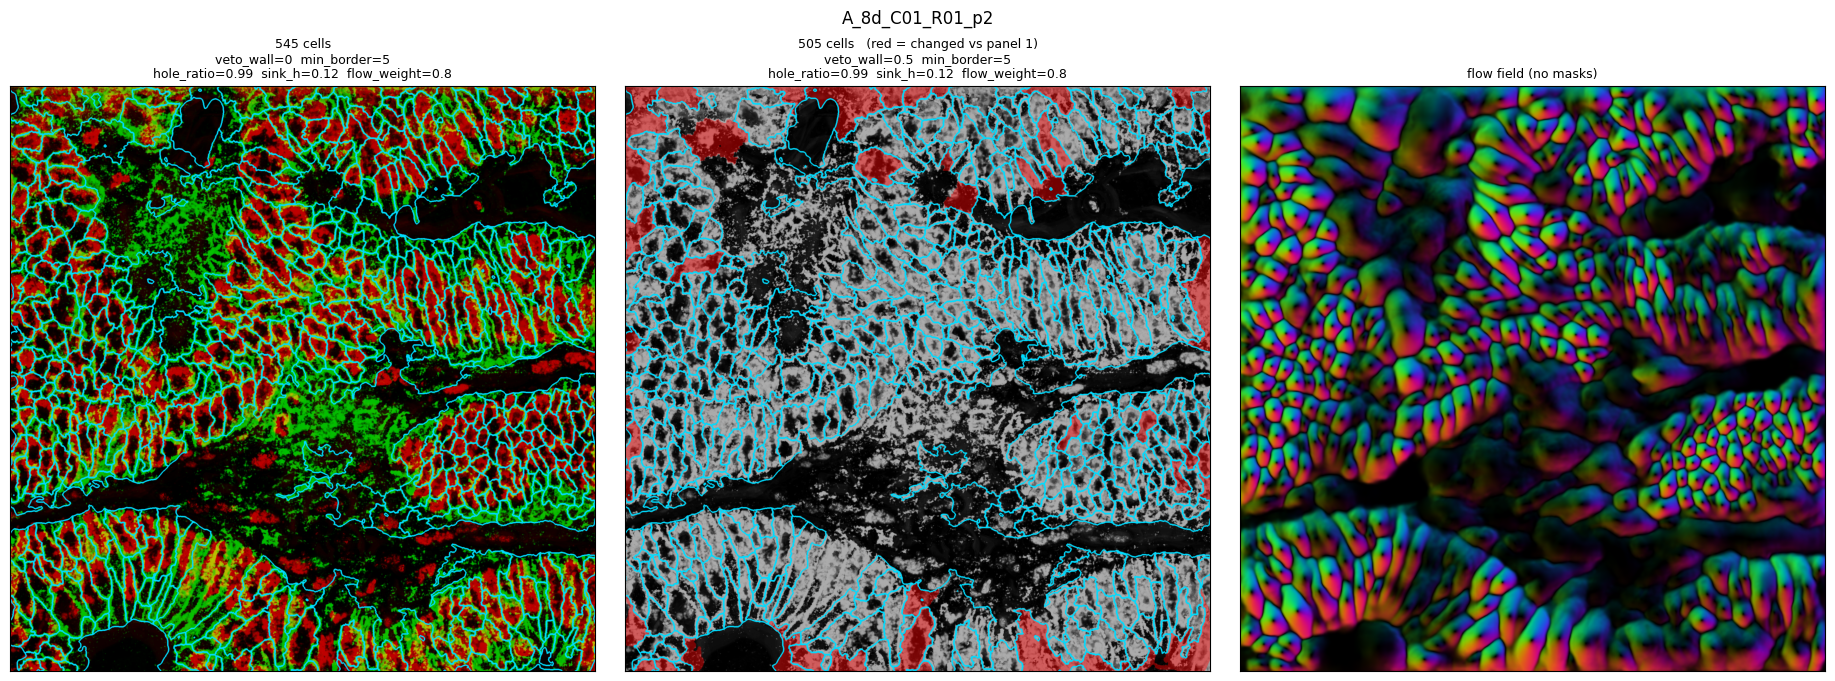

In [4]:
from scipy import sparse
from scipy.optimize import linear_sum_assignment

CHANGE_IOU = 0.8          # below this overlap, a cell counts as "changed"


def _iou(a, b):
    na, nb = int(a.max()), int(b.max())
    if na == 0 or nb == 0:
        return np.zeros((na, nb), np.float32)
    m = (a > 0) & (b > 0)
    inter = sparse.coo_matrix(
        (np.ones(int(m.sum()), np.float32), (a[m] - 1, b[m] - 1)),
        shape=(na, nb)).toarray()
    aa = np.bincount(a.ravel(), minlength=na + 1)[1:].astype(np.float32)
    bb = np.bincount(b.ravel(), minlength=nb + 1)[1:].astype(np.float32)
    return inter / np.maximum(aa[:, None] + bb[None, :] - inter, 1)


def changed_mask(A, B, thr=None):
    """Pixels belonging to a cell that is not 1:1 the same in A and B."""
    thr = CHANGE_IOU if thr is None else thr
    A, B = A.astype(np.int32), B.astype(np.int32)
    M = _iou(A, B)
    if M.size == 0:
        return (A > 0) | (B > 0)

    r, c = linear_sum_assignment(-M)
    keep = M[r, c] >= thr
    same_a, same_b = set((r[keep] + 1).tolist()), set((c[keep] + 1).tolist())

    bad_a = np.array([i for i in range(1, int(A.max()) + 1) if i not in same_a], np.int32)
    bad_b = np.array([j for j in range(1, int(B.max()) + 1) if j not in same_b], np.int32)

    out = np.zeros(A.shape, bool)
    if bad_a.size:
        out |= np.isin(A, bad_a)
    if bad_b.size:
        out |= np.isin(B, bad_b)
    return out


def compare(fov_path=None, settings=None, crop=None, figsize=None,
            width=None, dim=0.75, shade=0.45):
    """baseline | what changed under the 2nd setting | flow field."""
    fov_path = fov_path or fov_list()[0]
    settings = settings or SETTINGS
    crop     = CROP if crop is None else crop

    def params_of(item):
        return item[1] if isinstance(item, tuple) else item

    if len(settings) < 2:
        raise ValueError("SETTINGS needs at least two entries: a baseline and the "
                         "one you changed.")
    pA, pB = params_of(settings[0]), params_of(settings[1])

    seg = fm.load_seg(str(fov_path))
    labA, ctx = fm.run_pipeline(seg, pA)
    labB, _   = fm.run_pipeline(seg, pB)

    flow = np.asarray(seg["flows"][0])
    if flow.ndim == 4:
        flow = flow[0]

    H, W = ctx["membrane"].shape
    y0, x0, s = crop if crop else (0, 0, min(H, W))
    y0 = max(0, min(int(y0), H - 1)); x0 = max(0, min(int(x0), W - 1))
    s  = max(1, min(int(s), H - y0, W - x0))
    sl = np.s_[y0:y0 + s, x0:x0 + s]
    w = width or max(1, int(round(s / 1000)))

    base = np.zeros((s, s, 3), np.float32)
    base[..., 1] = np.clip(ctx["membrane"][sl], 0, 1) * dim     # membrane -> green
    base[..., 0] = np.clip(ctx["nucleus"][sl], 0, 1) * dim      # nucleus  -> red

    def txt(p, lab, extra=""):
        return (f"{int(lab.max())} cells{extra}\n"
                f"veto_wall={p.veto_wall}  min_border={p.veto_min_border}\n"
                f"hole_ratio={p.hole_ratio}  sink_h={p.sink_h}  flow_weight={p.flow_weight}")

    fig, ax = plt.subplots(1, 3, figsize=figsize or (18.6, 6.9))

    # 1: baseline
    p1 = base.copy()
    p1[dilation(find_boundaries(labA[sl], mode="inner"), disk(w))] = [0, .86, 1]
    ax[0].imshow(np.clip(p1, 0, 1))
    ax[0].set_title(txt(pA, labA), fontsize=9)

    # 2: only what changed, shaded red.
    # Background goes grey here - the nucleus channel is red too, so a red shade
    # on the colour image would be invisible.
    diff = changed_mask(labA, labB)[sl]
    grey = base.max(axis=2)
    p2 = np.repeat(grey[:, :, None], 3, axis=2) * 0.9
    p2[diff] = p2[diff] * (1 - shade) + np.array([1., 0., 0.], np.float32) * shade
    p2[dilation(find_boundaries(labB[sl], mode="inner"), disk(w))] = [0, .86, 1]
    ax[1].imshow(np.clip(p2, 0, 1))
    ax[1].set_title(txt(pB, labB, "   (red = changed vs panel 1)"), fontsize=9)

    # 3: flow field, no masks
    ax[2].imshow(np.clip(flow[sl].astype(np.float32) / 255.0 * 0.9, 0, 1))
    ax[2].set_title("flow field (no masks)", fontsize=9)

    for a in ax:
        a.set_xticks([]); a.set_yticks([])

    fig.suptitle(f"{fov_path.name.replace('_seg.npy','')}"
                 f"{'' if crop is None else f'   [y{y0}:{y0+s}, x{x0}:{x0+s}]'}")
    plt.tight_layout(rect=[0, 0, 1, 0.94])


for _f in fov_list():
    compare(_f)

---

## 5. Compare against the flow field

Same settings, but drawn on top of Cellpose's **flow direction map** instead of the
raw channels. The first panel is the flow on its own; each following panel adds one
setting's boundaries.

Each blob of colour converging on a dark centre is one cell as the *network* sees
it. So this answers a different question from cell 4: not "does this boundary sit
on membrane signal", but "does this boundary agree with the shape the flow field
implies". A contour cutting across a single colour blob is splitting one flow cell
in two; a contour enclosing several blobs is merging them.

Works best with **two** settings, giving three panels.

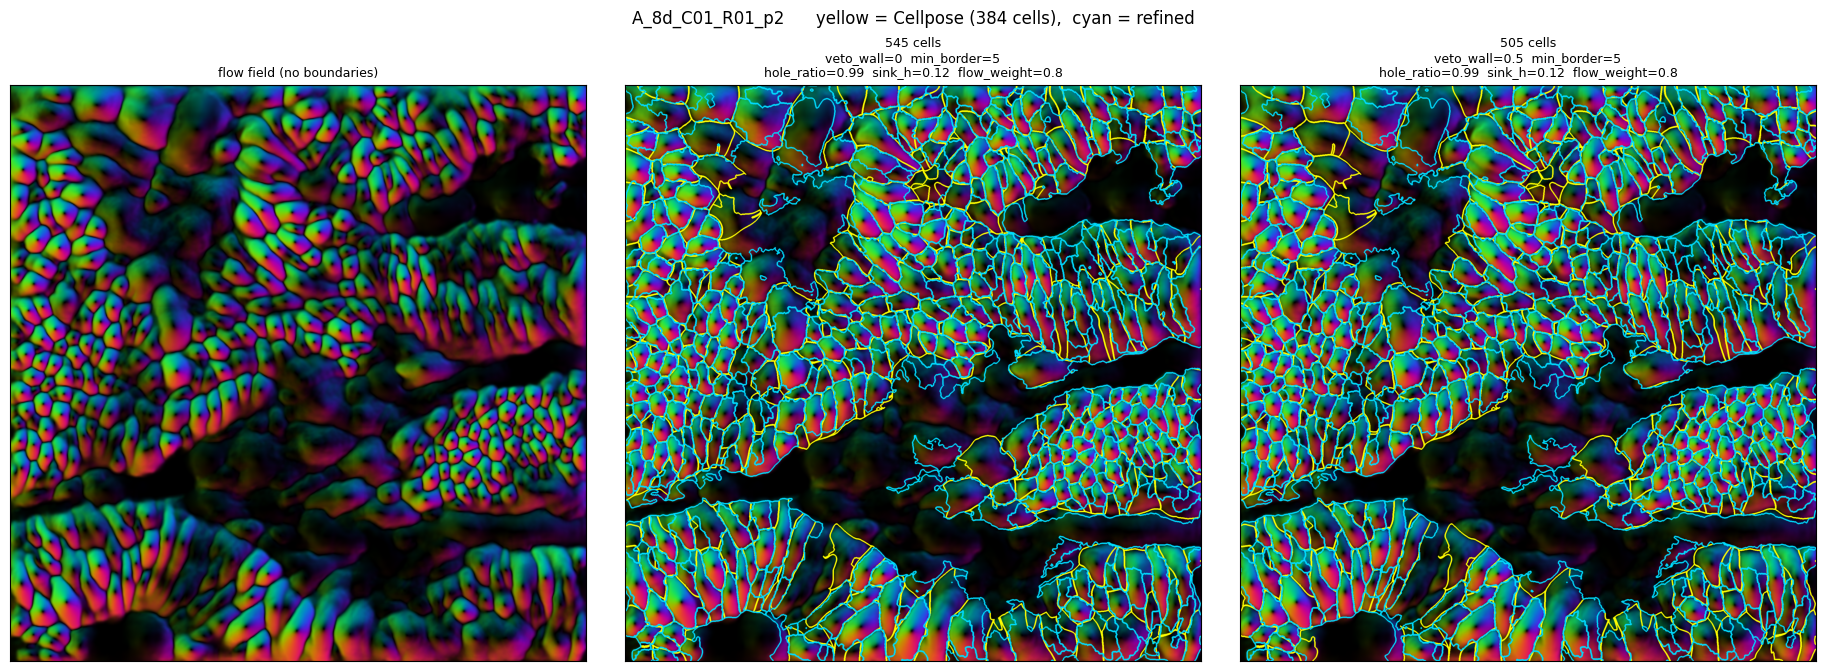

In [5]:
def compare_flow(fov_path=None, settings=None, crop=None, figsize=None,
                 width=None, dim=0.9):
    """Flow field alone, then the same flow field with each setting's boundaries."""
    fov_path = fov_path or fov_list()[0]
    settings = settings or SETTINGS
    crop     = CROP if crop is None else crop

    seg = fm.load_seg(str(fov_path))
    cellpose = np.asarray(seg["masks"]) if seg.get("masks") is not None else None

    flow = np.asarray(seg["flows"][0])
    if flow.ndim == 4:                       # cellpose stores it as (1, H, W, 3)
        flow = flow[0]

    results = []
    for item in settings:
        p = item[1] if isinstance(item, tuple) else item
        labels, ctx = fm.run_pipeline(seg, p)
        results.append((p, labels))

    H, W = flow.shape[:2]
    y0, x0, s = crop if crop else (0, 0, min(H, W))
    y0 = max(0, min(int(y0), H - 1)); x0 = max(0, min(int(x0), W - 1))
    s  = max(1, min(int(s), H - y0, W - x0))
    sl = np.s_[y0:y0 + s, x0:x0 + s]
    w = width or max(1, int(round(s / 1000)))

    base = np.clip(flow[sl].astype(np.float32) / 255.0 * dim, 0, 1)

    n = len(results) + 1
    figsize = figsize or (6.2 * n, 6.8)
    fig, ax = plt.subplots(1, n, figsize=figsize, squeeze=False)
    ax = ax[0]

    ax[0].imshow(base)
    ax[0].set_title("flow field (no boundaries)", fontsize=9)

    for a, (p, labels) in zip(ax[1:], results):
        rgb = base.copy()
        if cellpose is not None:
            rgb[dilation(find_boundaries(cellpose[sl], mode="inner"), disk(w))] = [1, 1, 0]
        rgb[dilation(find_boundaries(labels[sl], mode="inner"), disk(w))] = [0, .86, 1]
        a.imshow(rgb)
        a.set_title(f"{int(labels.max())} cells\n"
                    f"veto_wall={p.veto_wall}  min_border={p.veto_min_border}\n"
                    f"hole_ratio={p.hole_ratio}  sink_h={p.sink_h}  flow_weight={p.flow_weight}",
                    fontsize=9)

    for a in ax:
        a.set_xticks([]); a.set_yticks([])

    n_cp = 0 if cellpose is None else int(cellpose.max())
    fig.suptitle(f"{fov_path.name.replace('_seg.npy','')}"
                 f"{'' if crop is None else f'   [y{y0}:{y0+s}, x{x0}:{x0+s}]'}"
                 f"      yellow = Cellpose ({n_cp} cells),  cyan = refined")
    plt.tight_layout(rect=[0, 0, 1, 0.94])


for _f in fov_list():
    compare_flow(_f)

---

Each panel is a full `run_pipeline` on a 2048×2048 field, so three settings take a
moment.

At full-FOV scale the contours are about a pixel wide on screen — good for judging
overall behaviour, not individual boundaries. Set `CROP = (600, 600, 500)` in cell 3
and re-run to look closely.

---

## 6. Flag irregular masks

Masks that are clearly not cells: sprawling, branched, or tiny. Three tests, OR'd —
a mask is flagged if **any** of them fires:

- **`circularity`** = `4πA/P²`. Falls with total perimeter, so it catches branched
  and tentacle-like shapes. This is the one that does most of the work.
- **`thickness`** = `2·max(distance transform) / equivalent diameter`. How fat the
  mask is relative to its size — a disk scores 1.0, a thin sliver near 0. It never
  looks at the perimeter, so unlike circularity it is not fooled by ragged
  outlines. It catches slivers that circularity misses.
- **`area`** — fragments.

The two shape tests fail on *different* shapes, which is why both are here: a
branched blob can still contain one fat lobe (good thickness, bad circularity),
and a smooth sliver can have a tidy perimeter (good circularity, bad thickness).

The thresholds below are deliberately conservative — they should flag a small
handful per FOV, not reshape the segmentation. Raise them only if obvious junk
survives.

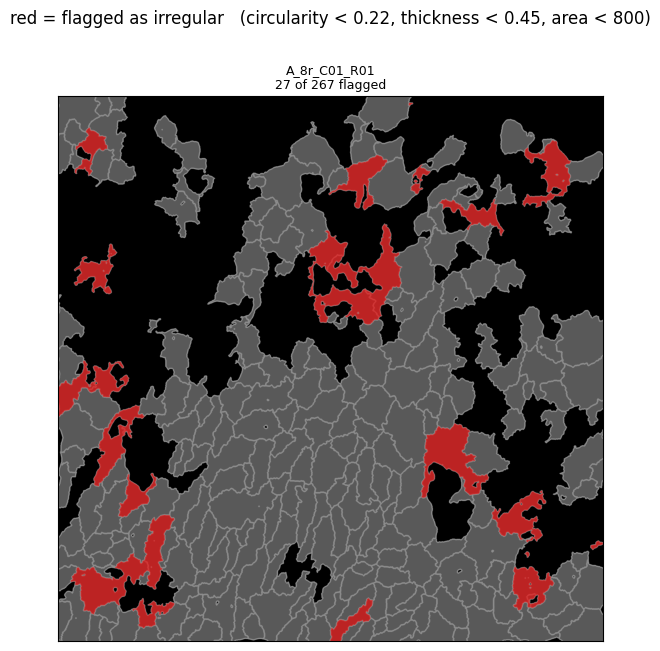

In [10]:
from scipy import ndimage as ndi
from skimage import measure

MIN_CIRCULARITY = 0.22      # below this -> flagged
MIN_THICKNESS   = 0.45      # below this -> flagged
MIN_AREA        = 800       # below this -> flagged


def cell_shape_metrics(lab):
    """{label: (circularity, thickness, area)} for one label image."""
    out = {}
    for r in measure.regionprops(lab):
        per = r.perimeter if r.perimeter > 0 else 1.0
        dt = ndi.distance_transform_edt(np.pad(r.image, 1))
        eq_d = 2 * np.sqrt(r.area / np.pi)
        out[r.label] = (4 * np.pi * r.area / per ** 2,
                        2 * dt.max() / max(eq_d, 1e-9),
                        r.area)
    return out


def irregular_labels(lab, min_circ=None, min_thick=None, min_area=None):
    """Labels failing any shape test."""
    min_circ  = MIN_CIRCULARITY if min_circ  is None else min_circ
    min_thick = MIN_THICKNESS   if min_thick is None else min_thick
    min_area  = MIN_AREA        if min_area  is None else min_area
    return {l for l, (c, t, a) in cell_shape_metrics(lab).items()
            if c < min_circ or t < min_thick or a < min_area}


def drop_irregular(lab, **kw):
    """Label image with the flagged masks removed (relabelled 1..N)."""
    bad = irregular_labels(lab, **kw)
    out = lab.copy()
    if bad:
        out[np.isin(lab, np.fromiter(bad, np.int32))] = 0
    from skimage.segmentation import relabel_sequential
    out, _, _ = relabel_sequential(out)
    return out


def show_irregular(fov_paths=None, p=None, crop=None, ncols=3, figsize=None, shade=0.6):
    """Grey masks with the flagged ones shaded red, one panel per FOV."""
    fov_paths = fov_paths or fov_list()
    crop      = CROP if crop is None else crop
    if p is None:
        first = SETTINGS[0]
        p = first[1] if isinstance(first, tuple) else first

    n = len(fov_paths)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize or (6.2 * ncols, 6.6 * nrows),
                           squeeze=False)
    axes = ax.ravel()

    for a, fp in zip(axes, fov_paths):
        seg = fm.load_seg(str(fp))
        lab, _ = fm.run_pipeline(seg, p)
        bad = irregular_labels(lab)

        H, W = lab.shape
        y0, x0, s = crop if crop else (0, 0, min(H, W))
        y0 = max(0, min(int(y0), H - 1)); x0 = max(0, min(int(x0), W - 1))
        s  = max(1, min(int(s), H - y0, W - x0))
        sl = np.s_[y0:y0 + s, x0:x0 + s]
        w = max(1, int(round(s / 1000)))

        sub = lab[sl]
        img = np.repeat(((sub > 0).astype(np.float32) * 0.35)[:, :, None], 3, axis=2)
        img[dilation(find_boundaries(sub, mode="inner"), disk(w))] = [.55, .55, .55]
        if bad:
            m = np.isin(sub, np.fromiter(bad, np.int32))
            img[m] = img[m] * (1 - shade) + np.array([1., 0., 0.], np.float32) * shade

        a.imshow(np.clip(img, 0, 1))
        a.set_title(f"{fp.name.replace('_seg.npy','')}\n"
                    f"{len(bad)} of {int(lab.max())} flagged", fontsize=9)

    for a in axes:
        a.set_xticks([]); a.set_yticks([])
    for a in axes[n:]:
        a.set_visible(False)

    fig.suptitle(f"red = flagged as irregular   "
                 f"(circularity < {MIN_CIRCULARITY}, thickness < {MIN_THICKNESS}, "
                 f"area < {MIN_AREA})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])


show_irregular()